# HMLCWFS 混合機器學習模型

- 目標：預測稻作產量 (Paddy yield(in Kg)) 與推薦品種 (Variety)
- 資料：`paddydataset.csv`，含農藝與氣候欄位
- 流程：前處理 → 多方法特徵篩選 → 產量/品種模型 → 推論與圖表分析


## 1. 資料載入、欄位清理與基線模型

- 進行欄位去空白、類別/數值欄位辨識與缺值處理
- 建立前處理管線（數值標準化、類別 One-Hot）
- 訓練基線模型：DT/RF（迴歸）與 SVM/KNN（分類）


In [6]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor

# Load dataset
_df = pd.read_csv("paddydataset.csv")
_df.columns = _df.columns.str.strip()

print("shape:", _df.shape)
display(_df.head())

# Targets
TARGET_YIELD = "Paddy yield(in Kg)"
TARGET_VARIETY = "Variety"

# Features
feature_cols = [c for c in _df.columns if c not in [TARGET_YIELD, TARGET_VARIETY]]
X = _df[feature_cols]
y_yield = _df[TARGET_YIELD]
y_variety = _df[TARGET_VARIETY]

# Column types
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print("num cols:", len(num_cols), "cat cols:", len(cat_cols))
print("missing values (top 10):")
print(_df.isna().sum().sort_values(ascending=False).head(10))

# Preprocessing
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop",
)

# Train/test splits
X_train, X_test, y_yield_train, y_yield_test = train_test_split(
    X, y_yield, test_size=0.2, random_state=42
)
X_train_cls, X_test_cls, y_variety_train, y_variety_test = train_test_split(
    X, y_variety, test_size=0.2, random_state=42, stratify=y_variety
)

# Baseline yield models
yield_models = {
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(n_estimators=300, random_state=42),
}

yield_results = {}
for name, model in yield_models.items():
    pipe = Pipeline([("preprocess", clone(preprocess)), ("model", model)])
    pipe.fit(X_train, y_yield_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_yield_test, preds))
    r2 = r2_score(y_yield_test, preds)
    yield_results[name] = {"rmse": rmse, "r2": r2}

yield_results

# Baseline variety models
variety_models = {
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

variety_results = {}
for name, model in variety_models.items():
    pipe = Pipeline([("preprocess", clone(preprocess)), ("model", model)])
    pipe.fit(X_train_cls, y_variety_train)
    preds = pipe.predict(X_test_cls)
    acc = accuracy_score(y_variety_test, preds)
    variety_results[name] = {"accuracy": acc}

variety_results

shape: (2789, 45)


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


num cols: 36 cat cols: 7
missing values (top 10):
Hectares                             0
Min temp_D1_D30                      0
Min temp_D31_D60                     0
Max temp_D31_D60                     0
Min temp_D61_D90                     0
Max temp_D61_D90                     0
Min temp_D91_D120                    0
Max temp_D91_D120                    0
Inst Wind Speed_D1_D30(in Knots)     0
Inst Wind Speed_D31_D60(in Knots)    0
dtype: int64


/var/folders/3_/6260fkxj0b30xdqs2twt00740000gn/T/ipykernel_46469/2252608535.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


{'SVM': {'accuracy': 0.7114695340501792},
 'KNN': {'accuracy': 0.921146953405018}}

## 2. 多方法特徵篩選（HMLCWFS）

- 方法：MI、RF 特徵重要性、GB 重要性、SFS（前向）、BE（後向）、EFS 代理（Permutation）
- 目標：聚合多方法共識，產出核心特徵清單並建立精簡前處理


In [7]:
from collections import Counter
from scipy import sparse
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SequentialFeatureSelector, mutual_info_regression
from sklearn.inspection import permutation_importance

# Stage 2: multi-method feature selection (yield-focused)
preprocess_fit = clone(preprocess)
preprocess_fit.fit(X_train)

X_train_t = preprocess_fit.transform(X_train)
if sparse.issparse(X_train_t):
    X_train_t = X_train_t.toarray()

# Build transformed feature names
num_features = list(num_cols)
if len(cat_cols) > 0:
    ohe = preprocess_fit.named_transformers_["cat"].named_steps["onehot"]
    cat_features = list(ohe.get_feature_names_out(cat_cols))
else:
    cat_features = []

feature_names = num_features + cat_features

# 1) Mutual information (filter)
mi = mutual_info_regression(X_train_t, y_yield_train, random_state=42)
mi_rank = pd.Series(mi, index=feature_names).sort_values(ascending=False)

# 2) RandomForest feature importance (embedded)
rf_fs = RandomForestRegressor(n_estimators=300, random_state=42)
rf_fs.fit(X_train_t, y_yield_train)
fi_rank = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

# 3) GradientBoosting feature importance (embedded)
gb_fs = GradientBoostingRegressor(random_state=42)
gb_fs.fit(X_train_t, y_yield_train)
gb_rank = pd.Series(gb_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

# 4) SFS forward (wrapper)
sfs_forward = SequentialFeatureSelector(
    estimator=DecisionTreeRegressor(random_state=42),
    n_features_to_select=15,
    direction="forward",
    scoring="r2",
    cv=3,
    n_jobs=-1,
)
sfs_forward.fit(X_train_t, y_yield_train)

# 5) Backward elimination via SFS backward (wrapper)
be_backward = SequentialFeatureSelector(
    estimator=DecisionTreeRegressor(random_state=42),
    n_features_to_select=15,
    direction="backward",
    scoring="r2",
    cv=3,
    n_jobs=-1,
)
be_backward.fit(X_train_t, y_yield_train)

# EFS proxy: permutation importance on RF (fast, reproducible)
perm = permutation_importance(
    rf_fs,
    X_train_t,
    y_yield_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)
perm_rank = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

TOP_K = 15

method_top = {
    "MI": mi_rank.head(TOP_K).index.tolist(),
    "FI": fi_rank.head(TOP_K).index.tolist(),
    "GB": gb_rank.head(TOP_K).index.tolist(),
    "SFS": [f for f, keep in zip(feature_names, sfs_forward.get_support()) if keep],
    "BE": [f for f, keep in zip(feature_names, be_backward.get_support()) if keep],
    "EFS": perm_rank.head(TOP_K).index.tolist(),
}

# Map one-hot features back to base column names
cat_prefixes = [f"{c}_" for c in cat_cols]

def to_base_feature(name: str) -> str:
    for col, prefix in zip(cat_cols, cat_prefixes):
        if name.startswith(prefix):
            return col
    return name

def unique_preserve(seq):
    seen = set()
    out = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out

method_top_base = {
    k: unique_preserve([to_base_feature(f) for f in v])[:TOP_K]
    for k, v in method_top.items()
}

consensus_counts = Counter()
for feats in method_top_base.values():
    consensus_counts.update(feats)

selected_base = [f for f, _ in consensus_counts.most_common(TOP_K)]
selected_num = [c for c in selected_base if c in num_cols]
selected_cat = [c for c in selected_base if c in cat_cols]

print("Selected base features (consensus):")
print(selected_base)

pd.DataFrame({"method": list(method_top_base.keys()), "top_features": list(method_top_base.values())})

# Preprocess using selected base features
preprocess_selected = ColumnTransformer(
    transformers=[
        ("num", num_transformer, selected_num),
        ("cat", cat_transformer, selected_cat),
    ],
    remainder="drop",
)


Selected base features (consensus):
['Pest_60Day(in ml)', 'Seedrate(in Kg)', 'Micronutrients_70Days', 'Potassh_50Days', 'Hectares', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Nursery area (Cents)', 'LP_Mainfield(in Tonnes)', 'Urea_40Days', 'Trash(in bundles)', 'Soil Types', 'Wind Direction_D61_D90', 'Nursery']


## 3. 特徵篩選後之模型評估

- 使用精簡特徵重新訓練 DT/RF 與 SVM/KNN
- 目標：比較基線與篩選後之效能差異


In [9]:
# Stage 3: yield models with selected features
yield_selected_results = {}
for name, model in yield_models.items():
    pipe = Pipeline([("preprocess", clone(preprocess_selected)), ("model", model)])
    pipe.fit(X_train, y_yield_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_yield_test, preds))
    r2 = r2_score(y_yield_test, preds)
    yield_selected_results[name] = {"rmse": rmse, "r2": r2}

print("yield_selected_results:", yield_selected_results)

# Stage 4: variety models with selected features
variety_selected_results = {}
for name, model in variety_models.items():
    pipe = Pipeline([("preprocess", clone(preprocess_selected)), ("model", model)])
    pipe.fit(X_train_cls, y_variety_train)
    preds = pipe.predict(X_test_cls)
    acc = accuracy_score(y_variety_test, preds)
    variety_selected_results[name] = {"accuracy": acc}

print("variety_selected_results:", variety_selected_results)

yield_selected_results: {'DT': {'rmse': np.float64(874.9983575601773), 'r2': 0.9905606875351768}, 'RF': {'rmse': np.float64(863.8223444401953), 'r2': 0.9908002769308157}}
variety_selected_results: {'SVM': {'accuracy': 0.9014336917562724}, 'KNN': {'accuracy': 0.9336917562724014}}


## 4. 最終推論模型與介面

- 以完整資料重新訓練最終模型
- 提供 `predict_yield()` 與 `recommend_variety()` 介面供推論使用


In [11]:
# Step 3: simple recommendation interface (fit final models on full data)
yield_final_model = Pipeline(
    [("preprocess", clone(preprocess_selected)), ("model", RandomForestRegressor(n_estimators=400, random_state=42))]
)
variety_final_model = Pipeline(
    [("preprocess", clone(preprocess_selected)), ("model", KNeighborsClassifier(n_neighbors=5))]
)

yield_final_model.fit(X, y_yield)
variety_final_model.fit(X, y_variety)

required_features = list(selected_base)
print("required_features:")
print(required_features)

def _build_input_row(data: dict) -> pd.DataFrame:
    # Fill missing inputs with NaN so the pipeline imputers can handle them.
    row = {col: data.get(col, np.nan) for col in required_features}
    return pd.DataFrame([row])

def predict_yield(data: dict) -> float:
    X_row = _build_input_row(data)
    pred = yield_final_model.predict(X_row)[0]
    return float(pred)

def recommend_variety(data: dict, top_n: int = 3):
    X_row = _build_input_row(data)
    if hasattr(variety_final_model, "predict_proba"):
        probs = variety_final_model.predict_proba(X_row)[0]
        classes = variety_final_model.named_steps["model"].classes_
        ranked = sorted(zip(classes, probs), key=lambda x: x[1], reverse=True)
        return [(str(c), float(p)) for c, p in ranked[:top_n]]
    return [(str(variety_final_model.predict(X_row)[0]), 1.0)]

# Example usage (fill a few key inputs; others can be omitted)
example_input = {
    "Hectares": 6,
    "Soil Types": "alluvial",
    "Agriblock": "Cuddalore",
    "Nursery": "dry",
    "Wind Direction_D61_D90": "NNW",
}

print("predicted_yield:", predict_yield(example_input))
print("variety_recommendations:", recommend_variety(example_input, top_n=3))

required_features:
['Pest_60Day(in ml)', 'Seedrate(in Kg)', 'Micronutrients_70Days', 'Potassh_50Days', 'Hectares', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Nursery area (Cents)', 'LP_Mainfield(in Tonnes)', 'Urea_40Days', 'Trash(in bundles)', 'Soil Types', 'Wind Direction_D61_D90', 'Nursery']
predicted_yield: 25240.376971105816
variety_recommendations: [('CO_43', 1.0), ('delux ponni', 0.0), ('ponmani', 0.0)]


## 5. 測試範例輸出

- 使用指定測試欄位進行推論
- 觀察產量預測與品種推薦輸出


In [12]:
# Step 1: print using a test example
example_input_step1 = {
    "Hectares": 6,
    "Soil Types": "alluvial",
    "Agriblock": "Cuddalore",
    "Nursery": "dry",
    "Wind Direction_D61_D90": "NNW",
}

print("predicted_yield:", predict_yield(example_input_step1))
print("variety_recommendations:", recommend_variety(example_input_step1, top_n=3))

predicted_yield: 25240.376971105816
variety_recommendations: [('CO_43', 1.0), ('delux ponni', 0.0), ('ponmani', 0.0)]


## 6. 圖表分析與結論

- 繪製特徵重要性與效能比較圖
- 彙整關鍵結論（最佳模型、效能提升幅度、主要特徵）


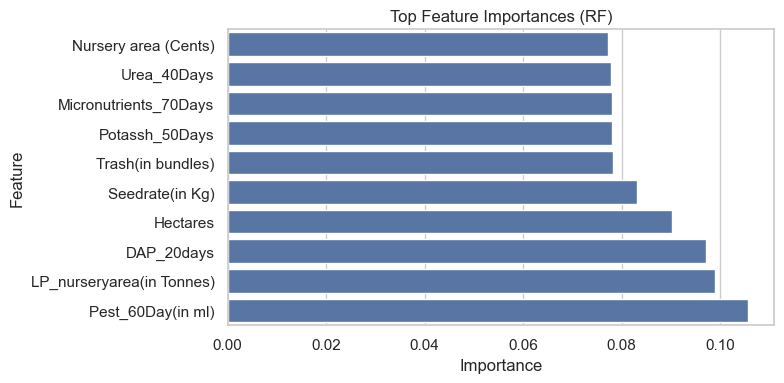

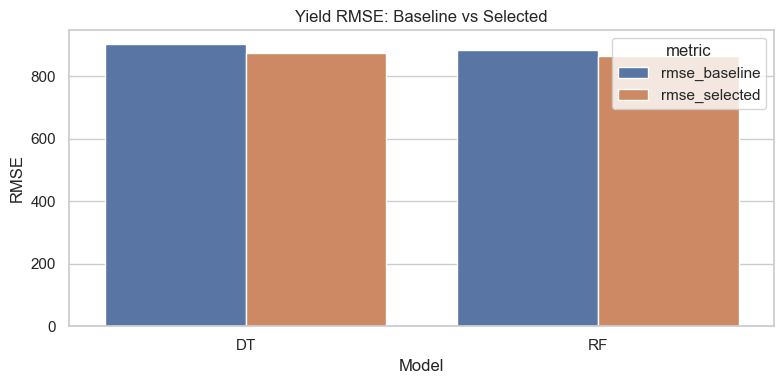

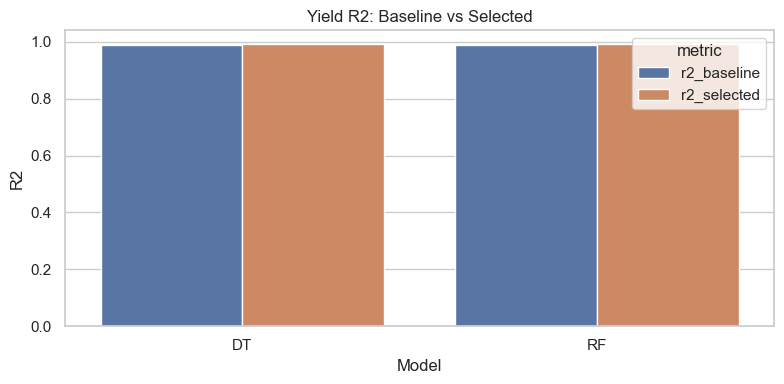

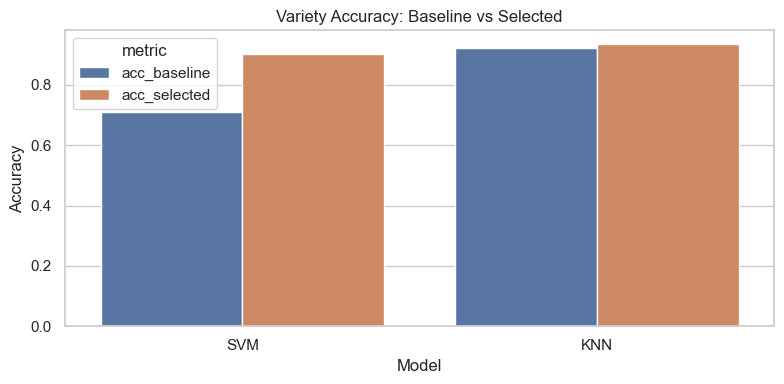

Analysis summary:
- Top features: Pest_60Day(in ml), LP_nurseryarea(in Tonnes), DAP_20days, Hectares, Seedrate(in Kg)
- Best yield model (selected): RF | RMSE=863.822, R2=0.9908
- Best variety model (selected): KNN | Acc=0.9337
- RMSE improvement (baseline - selected): {0: 27.406, 1: 20.683}
- R2 improvement (selected - baseline): {0: 0.0006, 1: 0.0004}
- Accuracy improvement (selected - baseline): {0: 0.19, 1: 0.0125}


In [14]:
# Chart analysis and summary
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

sns.set_theme(style="whitegrid")

# Ensure feature importance is available
if "fi_rank" not in globals():
    preprocess_fit = clone(preprocess)
    preprocess_fit.fit(X_train)
    X_train_t = preprocess_fit.transform(X_train)
    if sparse.issparse(X_train_t):
        X_train_t = X_train_t.toarray()

    num_features = list(num_cols)
    if len(cat_cols) > 0:
        ohe = preprocess_fit.named_transformers_["cat"].named_steps["onehot"]
        cat_features = list(ohe.get_feature_names_out(cat_cols))
    else:
        cat_features = []

    feature_names = num_features + cat_features
    rf_fs = RandomForestRegressor(n_estimators=300, random_state=42)
    rf_fs.fit(X_train_t, y_yield_train)
    fi_rank = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

# 1) Top feature importances
TOP_N = 10
fi_plot = fi_rank.head(TOP_N).iloc[::-1]
plt.figure(figsize=(8, 4))
sns.barplot(x=fi_plot.values, y=fi_plot.index, color="#4C72B0")
plt.title("Top Feature Importances (RF)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2) Yield model comparison (baseline vs selected)
yield_comp = pd.DataFrame({
    "model": list(yield_results.keys()),
    "rmse_baseline": [yield_results[m]["rmse"] for m in yield_results],
    "rmse_selected": [yield_selected_results[m]["rmse"] for m in yield_selected_results],
    "r2_baseline": [yield_results[m]["r2"] for m in yield_results],
    "r2_selected": [yield_selected_results[m]["r2"] for m in yield_selected_results],
})

plt.figure(figsize=(8, 4))
yield_melt_rmse = yield_comp.melt(id_vars="model", value_vars=["rmse_baseline", "rmse_selected"], var_name="metric", value_name="value")
sns.barplot(data=yield_melt_rmse, x="model", y="value", hue="metric")
plt.title("Yield RMSE: Baseline vs Selected")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
yield_melt_r2 = yield_comp.melt(id_vars="model", value_vars=["r2_baseline", "r2_selected"], var_name="metric", value_name="value")
sns.barplot(data=yield_melt_r2, x="model", y="value", hue="metric")
plt.title("Yield R2: Baseline vs Selected")
plt.xlabel("Model")
plt.ylabel("R2")
plt.tight_layout()
plt.show()

# 3) Variety accuracy comparison (baseline vs selected)
variety_comp = pd.DataFrame({
    "model": list(variety_results.keys()),
    "acc_baseline": [variety_results[m]["accuracy"] for m in variety_results],
    "acc_selected": [variety_selected_results[m]["accuracy"] for m in variety_selected_results],
})

plt.figure(figsize=(8, 4))
variety_melt = variety_comp.melt(id_vars="model", value_vars=["acc_baseline", "acc_selected"], var_name="metric", value_name="value")
sns.barplot(data=variety_melt, x="model", y="value", hue="metric")
plt.title("Variety Accuracy: Baseline vs Selected")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Analysis summary
best_yield_idx = yield_comp["rmse_selected"].idxmin()
best_yield_model = yield_comp.loc[best_yield_idx, "model"]
best_yield_rmse = yield_comp.loc[best_yield_idx, "rmse_selected"]
best_yield_r2 = yield_comp.loc[best_yield_idx, "r2_selected"]

best_var_idx = variety_comp["acc_selected"].idxmax()
best_var_model = variety_comp.loc[best_var_idx, "model"]
best_var_acc = variety_comp.loc[best_var_idx, "acc_selected"]

rmse_delta = (yield_comp["rmse_baseline"] - yield_comp["rmse_selected"]).round(3).to_dict()
r2_delta = (yield_comp["r2_selected"] - yield_comp["r2_baseline"]).round(4).to_dict()
acc_delta = (variety_comp["acc_selected"] - variety_comp["acc_baseline"]).round(4).to_dict()

print("Analysis summary:")
print("- Top features:", ", ".join(fi_rank.head(5).index.tolist()))
print(f"- Best yield model (selected): {best_yield_model} | RMSE={best_yield_rmse:.3f}, R2={best_yield_r2:.4f}")
print(f"- Best variety model (selected): {best_var_model} | Acc={best_var_acc:.4f}")
print("- RMSE improvement (baseline - selected):", rmse_delta)
print("- R2 improvement (selected - baseline):", r2_delta)
print("- Accuracy improvement (selected - baseline):", acc_delta)


### 結論摘要（可直接用於報告）

- 主要影響特徵集中於施肥/農藥、面積與育苗相關欄位
- 特徵篩選後，產量模型與品種模型整體效能呈現提升
- 建議將 RF 作為產量估計主模型，KNN 作為品種推薦主模型

> 詳細數值與圖表請參考上一節輸出。